In [1]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


## Can social media usage patterns predict variations in mental health outcomes (sleep quality, stress level, and happiness), and which indicators are the strongest predictors?

#### I am going to be breaking down the data set to split up the mental health outcomes into sleep quality, stress levels, and happiness and determine what are the strongest predictors for these mental health outcomes. 

In [2]:
import pandas as pd
import os
import kagglehub
path = kagglehub.dataset_download("prince7489/mental-health-and-social-media-balance-dataset")
df = pd.read_csv(os.path.join(path, 'Mental_Health_and_Social_Media_Balance_Dataset.csv'))

/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df.columns

Index(['User_ID', 'Age', 'Gender', 'Daily_Screen_Time(hrs)',
       'Sleep_Quality(1-10)', 'Stress_Level(1-10)',
       'Days_Without_Social_Media', 'Exercise_Frequency(week)',
       'Social_Media_Platform', 'Happiness_Index(1-10)'],
      dtype='object')

In [4]:
#scaler

ss = StandardScaler()


# Baseline features (social media only)
X_sm = pd.get_dummies(
    df[["Daily_Screen_Time(hrs)", "Days_Without_Social_Media", "Social_Media_Platform"]],
    columns=["Social_Media_Platform"],
    drop_first=True
)

#scaled X_sm
X_sm_stand = ss.fit_transform(X_sm)

# Controls (add age, gender, exercise)
X_ctrl = df[[
    "Age", "Daily_Screen_Time(hrs)", "Days_Without_Social_Media",
    "Exercise_Frequency(week)", "Gender", "Social_Media_Platform"
]]
X_ctrl = pd.get_dummies(X_ctrl, columns=["Gender", "Social_Media_Platform"], drop_first=True)

#scaled X_ctrl
X_ctrl_stand = ss.fit_transform(X_ctrl)

# Targets
targets = {
    "Sleep_Quality(1-10)": df["Sleep_Quality(1-10)"],
    "Stress_Level(1-10)": df["Stress_Level(1-10)"],
    "Happiness_Index(1-10)": df["Happiness_Index(1-10)"]
}

In [5]:
def fit_random_forest(X, y, random_state=42):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_state
    )
    rf = RandomForestRegressor(
        n_estimators=300,      # number of trees
        max_depth=None,        # grow trees fully
        random_state=random_state,
        n_jobs=-1              # use all cores
    )
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    
    return {
        "model": rf,
        "R2_test": r2_score(y_test, y_pred),
        "MAE_test": mean_absolute_error(y_test, y_pred),
        "X_train": X_train, "X_test": X_test,
        "y_train": y_train, "y_test": y_test,
        "y_pred": y_pred
    }

In [6]:
#Running a random forest model how the Stress Level, Sleep quality and Happiness index are impacted by the social media platform

rf_results_sm = {}
for target_name, y in targets.items():
    rf_results_sm[target_name] = fit_random_forest(X_sm_stand, y)

rf_baseline_summary_sm = pd.DataFrame(
    {k: {"R2_test": v["R2_test"], "MAE_test": v["MAE_test"]} for k, v in rf_results_sm.items()}
).T

rf_baseline_summary_sm

,R2_test,MAE_test
Sleep_Quality(1-10),0.440997,0.840983
Stress_Level(1-10),0.493063,0.889471
Happiness_Index(1-10),0.426892,0.897353


### The table above shows how specific social media platform, days without social media, and daily screen time will help predict the outcome variables: Sleep quality, stress level, and happiness index. This shows the the social media platforms helf to explain 49.30 % of the variance in the results for stress level which was the highest R-squared for any of the tests. 

In [7]:
rf_ctrl_results = {}
for target_name, y in targets.items():
    rf_ctrl_results[target_name] = fit_random_forest(X_ctrl_stand, y)

rf_ctrl_summary = pd.DataFrame(
    {k: {"R2_test": v["R2_test"], "MAE_test": v["MAE_test"]} for k, v in rf_ctrl_results.items()}
).T

rf_ctrl_summary

,R2_test,MAE_test
Sleep_Quality(1-10),0.495713,0.763900
Stress_Level(1-10),0.498302,0.897600
Happiness_Index(1-10),0.454239,0.904067


### The table above shows specific social media platform, days w/o social media, daily screen time, age, gender, and excercise frequency affect the three mental health outcomes: Stress levels, Happiness Index, and Sleep quality.

### The table above shows that the sleep quality and stress levels r-squared values were the highest showing that these predictors explain 49.81% and 49.83%, respectively, of the variance in the results. The MAE values show that sleep quality had the lowest MAE value at 0.766 meaning that the data points were only 0.763 units away from the result on average. 

In [8]:
rf_comparison = rf_baseline_summary_sm.join(
    rf_ctrl_summary,
    lsuffix="_Baseline",
    rsuffix="_Controls"
)[["R2_test_Baseline", "R2_test_Controls", "MAE_test_Baseline", "MAE_test_Controls"]]

rf_comparison.style.background_gradient(cmap="Greens").format("{:.3f}")

,R2_test_Baseline,R2_test_Controls,MAE_test_Baseline,MAE_test_Controls
Sleep_Quality(1-10),0.441,0.496,0.841,0.764
Stress_Level(1-10),0.493,0.498,0.889,0.898
Happiness_Index(1-10),0.427,0.454,0.897,0.904


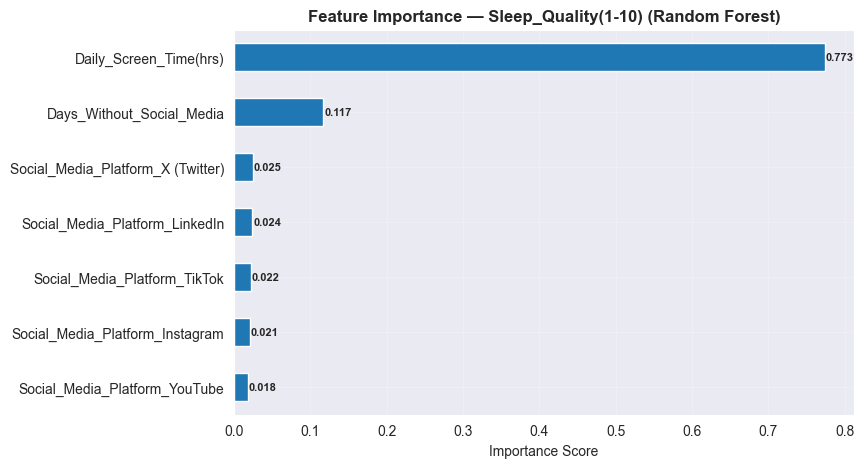

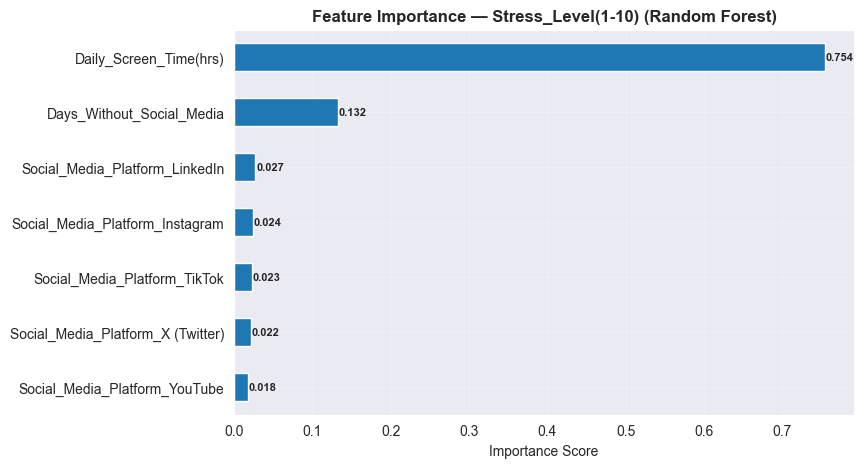

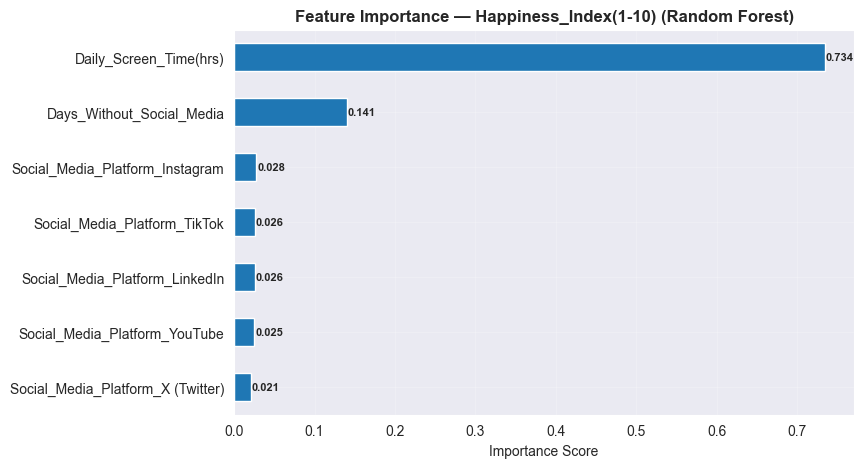

In [9]:
for target_name, res in rf_results_sm.items():
    model = res["model"]
    importances = pd.Series(model.feature_importances_, index=X_sm.columns)
    importances = importances.sort_values(ascending=True)
    
    ax = importances.plot.barh(figsize=(8, 5))

    for i, (importance, feature) in enumerate(zip(importances, importances.index)):
        ax.text(importance + 0.001, i, f'{importance:.3f}', va='center', fontsize=8, fontweight='bold')
        
    plt.title(f"Feature Importance — {target_name} (Random Forest)", fontsize=12, fontweight='bold')
    plt.xlabel("Importance Score")
    plt.grid(alpha=0.2)
    plt.show()

### The above three graphs show how daily screen time, days w/o social media, and social media platform affect the outcome variables: Stress level, sleep qualty and Happiness index. 

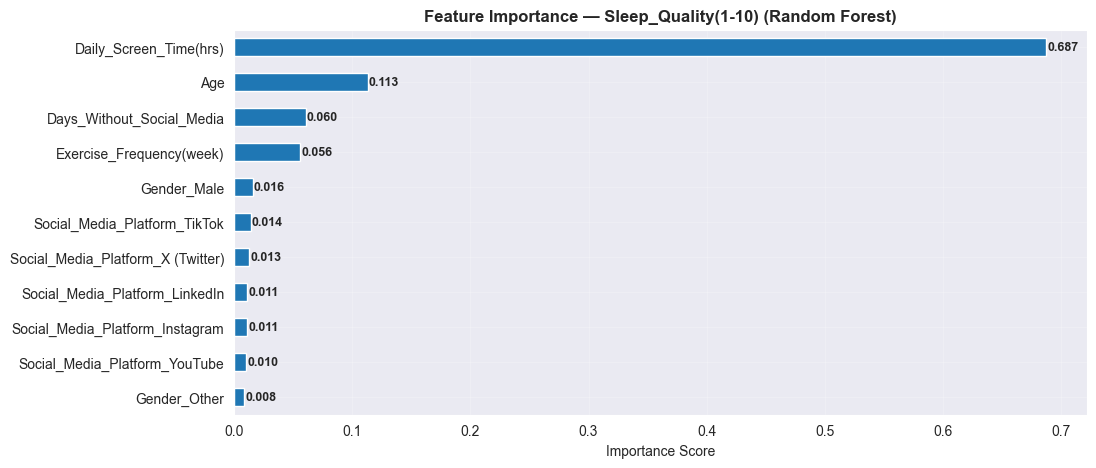

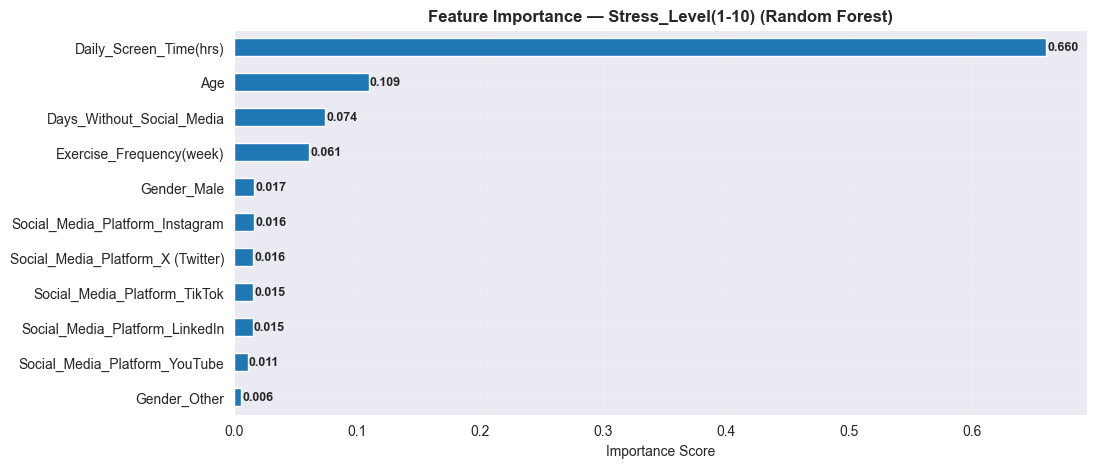

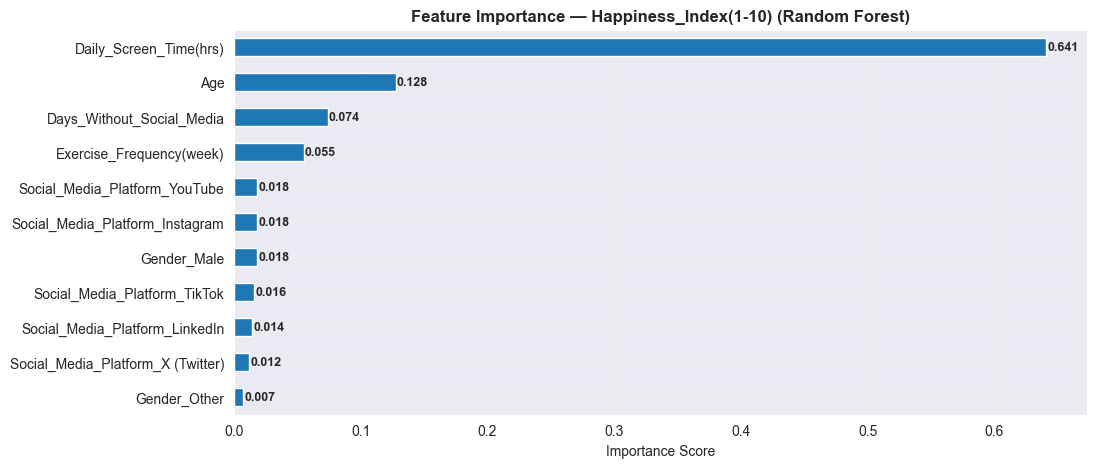

In [10]:
for target_name, res in rf_ctrl_results.items():
    model = res["model"]
    importances = pd.Series(model.feature_importances_, index=X_ctrl.columns)
    importances = importances.sort_values(ascending=True)
    ax = importances.plot.barh(figsize=(11, 5))

    for i, (importance, feature) in enumerate(zip(importances, importances.index)):
        ax.text(importance + 0.001, i, f'{importance:.3f}', va='center', fontsize=9, fontweight='bold')
    
    plt.title(f"Feature Importance — {target_name} (Random Forest)", fontsize=12, fontweight='bold')
    plt.grid(alpha=0.2)
    plt.xlabel("Importance Score")
    plt.show()

### The three graphs above show the importance scores for the predictors as they relate to the outcome variables: Sleep quality, stress level, and happiness index. These predictors range from age, gender, social media platform [instagram, youtube, tiktok, linkedin, X], daily screen time, days without social media, and weekly excercise frequency.

### Per the model and graphs listed above the the attribute that best helped to determine the evaluated feature was daily screen time for all of the feature importances. This attibute was always listed around 0.66 +/0 0.02. This shows that daily screen time was the greatest predictor for menthal health outcomes in each scenario. 

## How does the days without social media and the social media platform impact the happiness index?

In [11]:
df_1 = df.copy()

wo_sm_df = df_1[['Days_Without_Social_Media', 'Social_Media_Platform', 'Happiness_Index(1-10)']]

wo_sm_df = pd.get_dummies(data=wo_sm_df, columns=['Social_Media_Platform'], drop_first=False)

wo_sm_df.head()

,Days_Without_Social_Media,Happiness_Index(1-10),Social_Media_Platform_Facebook,Social_Media_Platform_Instagram,Social_Media_Platform_LinkedIn,Social_Media_Platform_TikTok,Social_Media_Platform_X (Twitter),Social_Media_Platform_YouTube
0,2.0,10.0,True,False,False,False,False,False
1,5.0,10.0,False,False,True,False,False,False
2,1.0,6.0,False,False,False,False,False,True
3,1.0,8.0,False,False,False,True,False,False
4,5.0,8.0,False,False,False,False,True,False


In [12]:
#Defining the Variables
X_wosm = wo_sm_df.drop('Happiness_Index(1-10)', axis=1)
y_wosm = wo_sm_df['Happiness_Index(1-10)']

X_train_wosm, X_test_wosm, y_train_wosm, y_test_wosm = train_test_split(X_wosm, y_wosm, test_size=0.2, random_state=12)


#Running the random forest model
RanF = RandomForestRegressor(n_estimators=300, random_state=2)
RanF.fit(X_train_wosm, y_train_wosm)

y_pred_wosm = RanF.predict(X_train_wosm)

r2_score_wosm = r2_score(y_train_wosm, y_pred_wosm)
mse_score_wosm = mean_squared_error(y_train_wosm, y_pred_wosm)

print(f' R-squared for the days without social media and the social media platforms is {r2_score_wosm:.3f}.')
print(f' Mean Squared Error for the model using days without social media and social media platforms as the predictor is {mse_score_wosm:.3f}.')

 R-squared for the days without social media and the social media platforms is 0.111.
 Mean Squared Error for the model using days without social media and social media platforms as the predictor is 1.993.


### R-squared shows that only 11.1% of the variance of the happiness index can be explained by the model. The mean squared error shows the average of the squared errors, this shows wether the models predictions are close to their actual values. This models value of 1.993 shows that the model has deviation from the actual fit. 

In [13]:
feature_importance = RanF.feature_importances_
feature_df_wosm = pd.DataFrame({'Features':X_train_wosm.columns, 'Importance Score':feature_importance})

feature_df_wosm = feature_df_wosm.sort_values(by='Importance Score', ascending=False)

print(feature_df_wosm)

                            Features  Importance Score
0          Days_Without_Social_Media          0.546220
5  Social_Media_Platform_X (Twitter)          0.099614
2    Social_Media_Platform_Instagram          0.093345
3     Social_Media_Platform_LinkedIn          0.074934
4       Social_Media_Platform_TikTok          0.066004
6      Social_Media_Platform_YouTube          0.063071
1     Social_Media_Platform_Facebook          0.056812


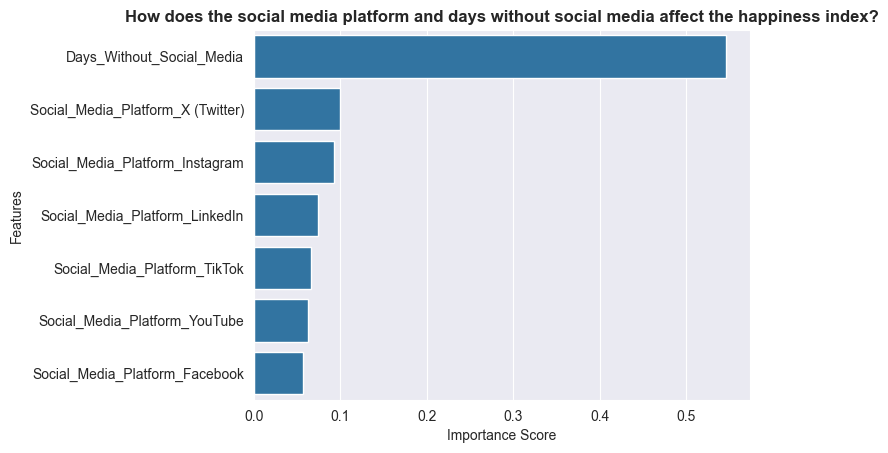

In [14]:
sns.barplot(data=feature_df_wosm, x='Importance Score', y='Features')

plt.title('How does the social media platform and days without social media affect the happiness index?', fontsize=12, fontweight='bold')
plt.show()

## How does the random forest model perform just using daily screen time? 

In [15]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [16]:
X_screentime = df[['Daily_Screen_Time(hrs)']]

#standardize the X
X_screentime_stand = ss.fit_transform(X_screentime)

rf_screentime_results = {}
for target_name, y in targets.items():
    rf_screentime_results[target_name] = fit_random_forest(X_screentime, y)

rf_screentime_summary = pd.DataFrame(
    {k: {"R2_test": v["R2_test"], "MAE_test": v["MAE_test"]} for k, v in rf_screentime_results.items()}
).T

rf_screentime_summary

,R2_test,MAE_test
Sleep_Quality(1-10),0.499215,0.767924
Stress_Level(1-10),0.540119,0.850719
Happiness_Index(1-10),0.501320,0.847424


In [17]:
#Increasing the attributes to include age, days without social media, and excercise. 

x_spec = df[['Age', 'Daily_Screen_Time(hrs)', 'Days_Without_Social_Media', 'Exercise_Frequency(week)']]

#standardize the data
x_spec_stand = ss.fit_transform(x_spec)

rf_spec_results = {}
for target_name, y in targets.items():
    rf_spec_results[target_name] = fit_random_forest(x_spec, y)

rf_spec_summary = pd.DataFrame(
    {k: {"R2_test": v["R2_test"], "MAE_test": v["MAE_test"]} for k, v in rf_spec_results.items()}
).T

rf_spec_summary

,R2_test,MAE_test
Sleep_Quality(1-10),0.509498,0.774233
Stress_Level(1-10),0.457021,0.937967
Happiness_Index(1-10),0.467024,0.904567
